# Synthetic Pairing Design

## Objective
This notebook constructs the synthetic multimodal pairing framework. The emphasis is on making the pairing logic explicit and measurable rather than pretending the paired samples represent real matched patients.


In [1]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'src').exists() and (CWD / 'data').exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'src').exists() and (CWD.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent
elif (CWD.parent.parent / 'src').exists() and (CWD.parent.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent.parent
else:
    raise RuntimeError(f'Could not resolve dissertation_project root from {CWD}')

REPO_ROOT = PROJECT_ROOT.parent
OUTPUTS = PROJECT_ROOT / 'outputs_v2'
FIGURES = OUTPUTS / 'figures'
METRICS = OUTPUTS / 'metrics'
REPORTS = OUTPUTS / 'reports'
MODELS = PROJECT_ROOT / 'models'
DATA_ROOT = PROJECT_ROOT / 'data' / 'dataset_cancer_v1' / 'dataset_cancer_v1'
WISCONSIN_ROOT = PROJECT_ROOT / 'notebook_Wisconsin'

for path in [FIGURES, METRICS, REPORTS]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)
print('Outputs:', OUTPUTS)

from IPython.display import display

from src.breakhis import build_binary_records, patient_level_split, sample_per_patient
from src.fusion import aggregate_image_embeddings, extract_image_embeddings, load_frozen_wisconsin_dataframe
from src.pairing import add_consistency_flag, build_random_pairs, build_same_label_pairs

wisconsin = load_frozen_wisconsin_dataframe(WISCONSIN_ROOT / 'brca.csv')
df = build_binary_records(DATA_ROOT)
split = patient_level_split(df, random_state=SEED)
image_source = pd.concat(
    [
        sample_per_patient(split.train, per_magnification=1, random_state=SEED),
        sample_per_patient(split.val, per_magnification=1, random_state=SEED),
        sample_per_patient(split.test, per_magnification=1, random_state=SEED),
    ],
    ignore_index=True,
)
image_embeddings = aggregate_image_embeddings(extract_image_embeddings(image_source, MODELS / 'breakhis_resnet18_patient_level_clean.pth'))
image_embeddings.to_csv(REPORTS / 'breakhis_patient_level_embeddings.csv', index=False)
print('Wisconsin rows:', len(wisconsin))
print('Image embedding rows:', len(image_embeddings))


Project root: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project
Outputs: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs_v2


Wisconsin rows: 569
Image embedding rows: 82


In [2]:
same_label_pairs = add_consistency_flag(build_same_label_pairs(wisconsin, image_embeddings, random_state=11).paired)
random_pairs = add_consistency_flag(build_random_pairs(wisconsin, image_embeddings, random_state=11).paired)
consistency_summary = pd.DataFrame(
    [
        {'pairing_type': 'same_label', 'match_rate': same_label_pairs['pair_label_match'].mean()},
        {'pairing_type': 'random', 'match_rate': random_pairs['pair_label_match'].mean()},
    ]
)
consistency_summary.to_csv(REPORTS / 'synthetic_pairing_consistency_summary.csv', index=False)
consistency_summary


,pairing_type,match_rate
0,same_label,1.000000
1,random,0.428822


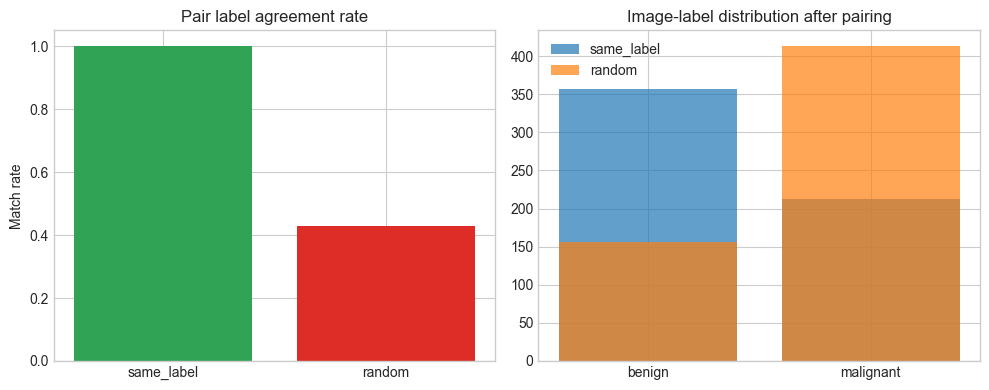

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(consistency_summary['pairing_type'], consistency_summary['match_rate'], color=['#31a354', '#de2d26'])
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Pair label agreement rate')
axes[0].set_ylabel('Match rate')

same_counts = same_label_pairs['img_label'].value_counts().rename_axis('label').reset_index(name='count')
random_counts = random_pairs['img_label'].value_counts().rename_axis('label').reset_index(name='count')
axes[1].bar(same_counts['label'], same_counts['count'], alpha=0.7, label='same_label')
axes[1].bar(random_counts['label'], random_counts['count'], alpha=0.7, label='random')
axes[1].set_title('Image-label distribution after pairing')
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURES / 'synthetic_pairing_design_summary.png', dpi=300)
plt.show()


In [4]:
seed_preview_rows = []
for seed in [11, 21, 31, 41, 51]:
    same = add_consistency_flag(build_same_label_pairs(wisconsin, image_embeddings, random_state=seed).paired)
    rand = add_consistency_flag(build_random_pairs(wisconsin, image_embeddings, random_state=seed).paired)
    seed_preview_rows.append({'seed': seed, 'pairing_type': 'same_label', 'match_rate': same['pair_label_match'].mean()})
    seed_preview_rows.append({'seed': seed, 'pairing_type': 'random', 'match_rate': rand['pair_label_match'].mean()})
seed_preview_df = pd.DataFrame(seed_preview_rows)
seed_preview_df.to_csv(REPORTS / 'synthetic_pairing_seed_preview.csv', index=False)
seed_preview_df


,seed,pairing_type,match_rate
0,11,same_label,1.000000
1,11,random,0.428822
2,21,same_label,1.000000
3,21,random,0.439367
4,31,same_label,1.000000
5,31,random,0.483304
6,41,same_label,1.000000
7,41,random,0.441125
8,51,same_label,1.000000
9,51,random,0.414763


## Interpretation

Same-label pairing is intentionally label-consistent, while the random control breaks that artificial alignment. The entire fusion study depends on treating this distinction honestly: if the same-label version looks much stronger than the control, that is not automatically evidence of meaningful multimodal learning.
